In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Get the dataset
df_averaged = pd.read_csv('../../../data/processed/climate_archetypes_avg.csv')

# Drop non numerical values
X = df_averaged.drop(columns=['country_code', 'Name'])

# Scale using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Print the first few rows of the scaled data
print(X_scaled[:5])

# Compare with unscaled data
print(X[:5])

# Which scaling method is best for K-Means? StandardScaler?
# Use standard scalar



[[-1.41461879 -0.84658028 -0.97341396 -0.74066657 -0.26967081 -0.73084449
  -0.4235797  -1.64253359 -0.65696832  0.36524349 -0.21754523 -0.48381774
  -0.91303554 -0.63969198 -0.25046356 -0.7085851  -1.2546315   0.21814707
  -0.18372608 -0.3771779  -1.06570477]
 [ 0.8474257   2.11625242  1.69939605  0.74087044 -0.00800194  1.11256326
   2.76820072 -0.38011537 -0.72934035 -0.30677566 -0.46212763  1.93172864
  -0.91303554 -0.63969198 -0.25046356  0.178051   -0.88034265  1.72174385
  -0.18372608 -1.0018085   1.25593343]
 [ 0.97178973  0.0942862  -0.66923633  0.08364969 -0.3258926   0.62990071
  -0.06287677  0.28517891  0.68375423 -0.30677566 -0.46212763 -0.48381774
   1.16783616  0.3663926  -0.25046356  0.63910178  0.84138605  0.98361452
  -0.18372608  0.10048079  0.38965052]
 [ 0.17644648  0.44088956 -0.71335098  0.59143869 -0.29862119  0.48979129
   0.29548196  0.20163514 -0.88727084 -0.30677566 -0.46212763 -0.48381774
   1.16783616  0.67896257 -0.25046356  1.59666876  0.84138605 -1.0667

# Visualising OG set

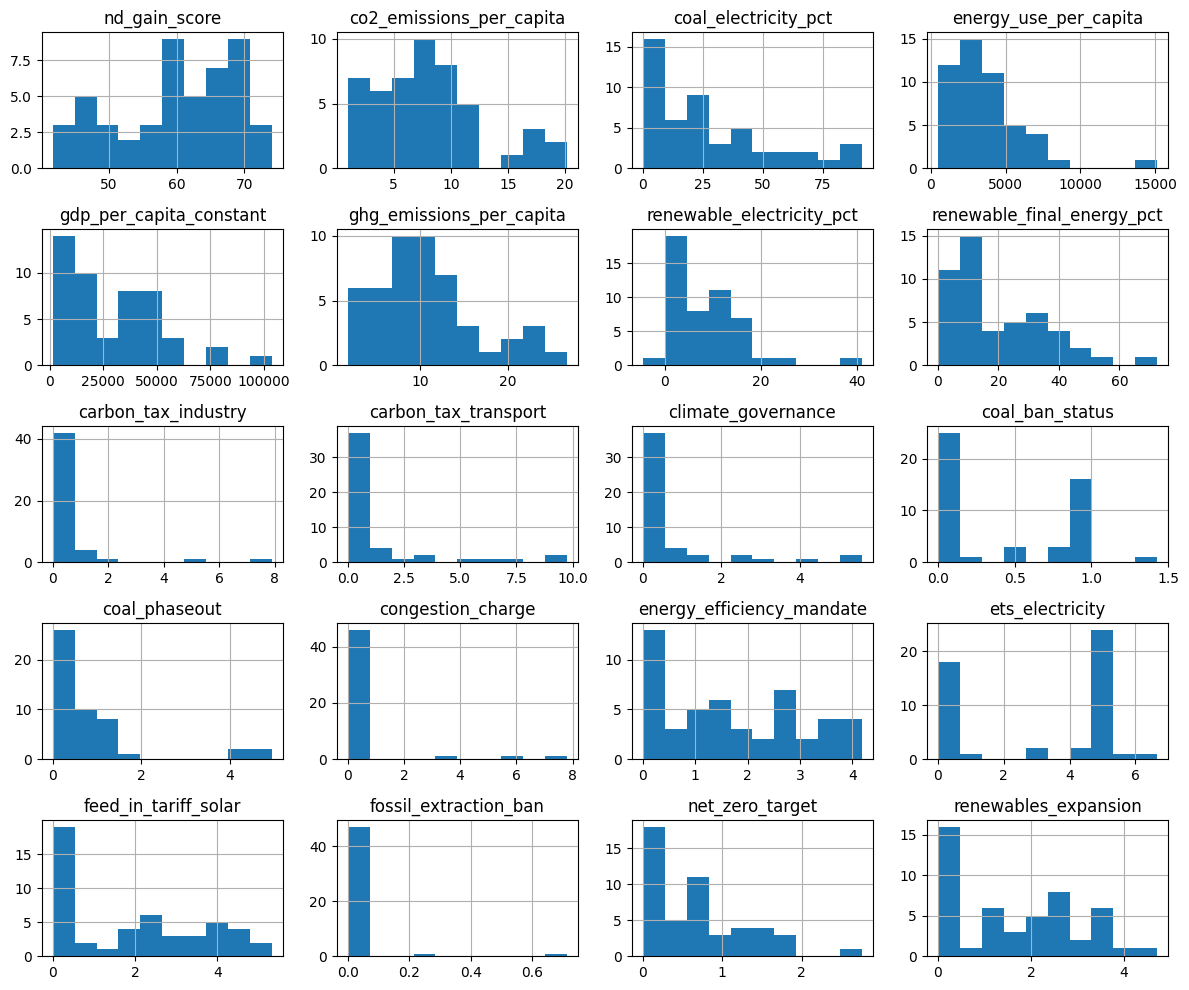

In [5]:
# Simple visualisation of distibution of og set

# remove gdp constant
df_averaged = df_averaged.drop(columns=['gdp_constant_usd'])

df_averaged.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


New Mean (should be ~0): 3.2907485180823405e-18
New Std (should be ~1): 1.0103629710818454


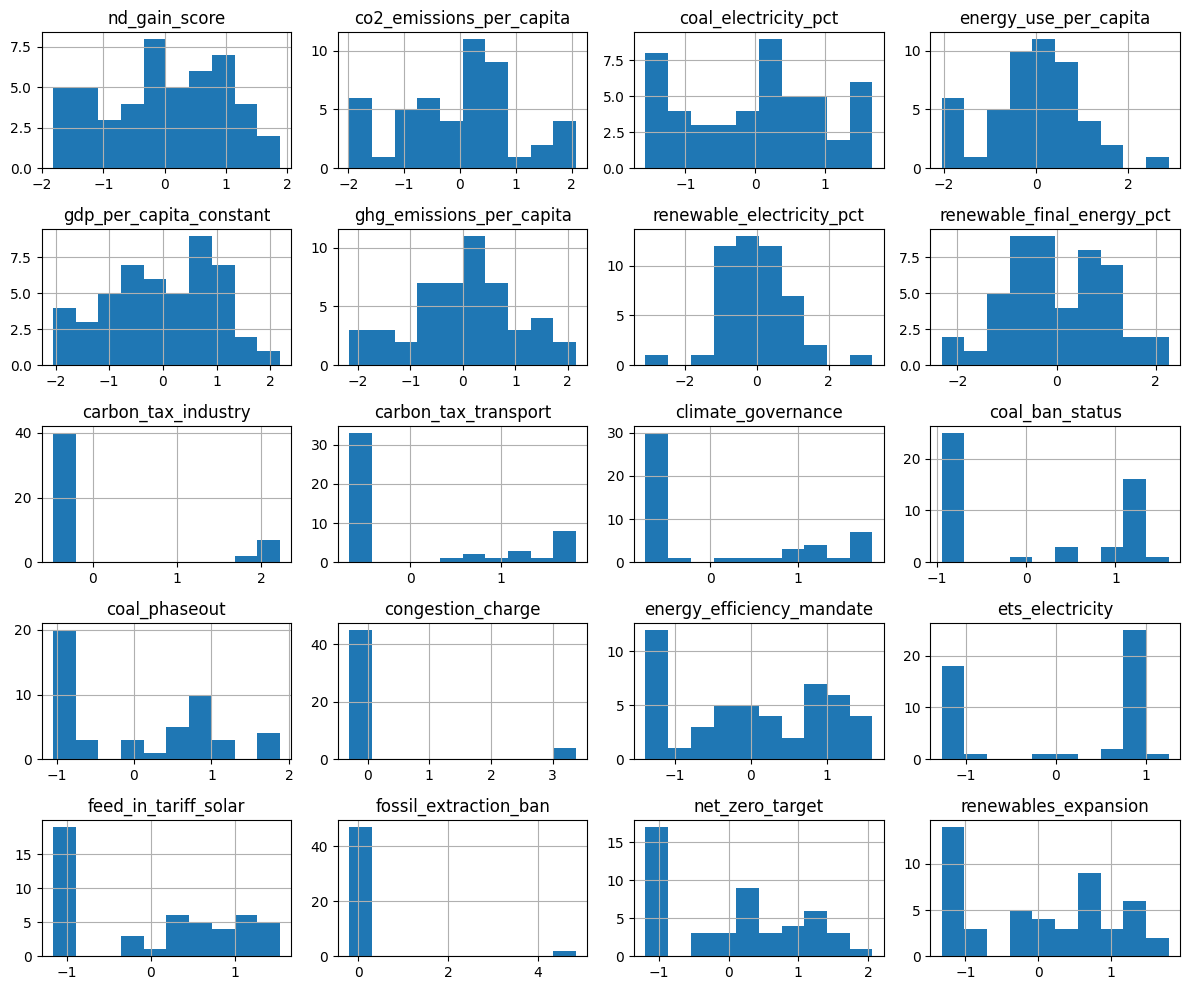

In [7]:


from sklearn.preprocessing import StandardScaler, PowerTransformer
# Apply PowerTransformer (Yeo-Johnson) 
pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X)


# Convert to DataFrame to check results
X_df = pd.DataFrame(X_transformed, columns=X.columns)
print("New Mean (should be ~0):", X_df.mean().mean())
print("New Std (should be ~1):", X_df.std().mean())


# Simple visualisation of distibution of og set
# drop gdp constant
X_df = X_df.drop(columns=['gdp_constant_usd'])
X_df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'Feature Redundancy Audit')

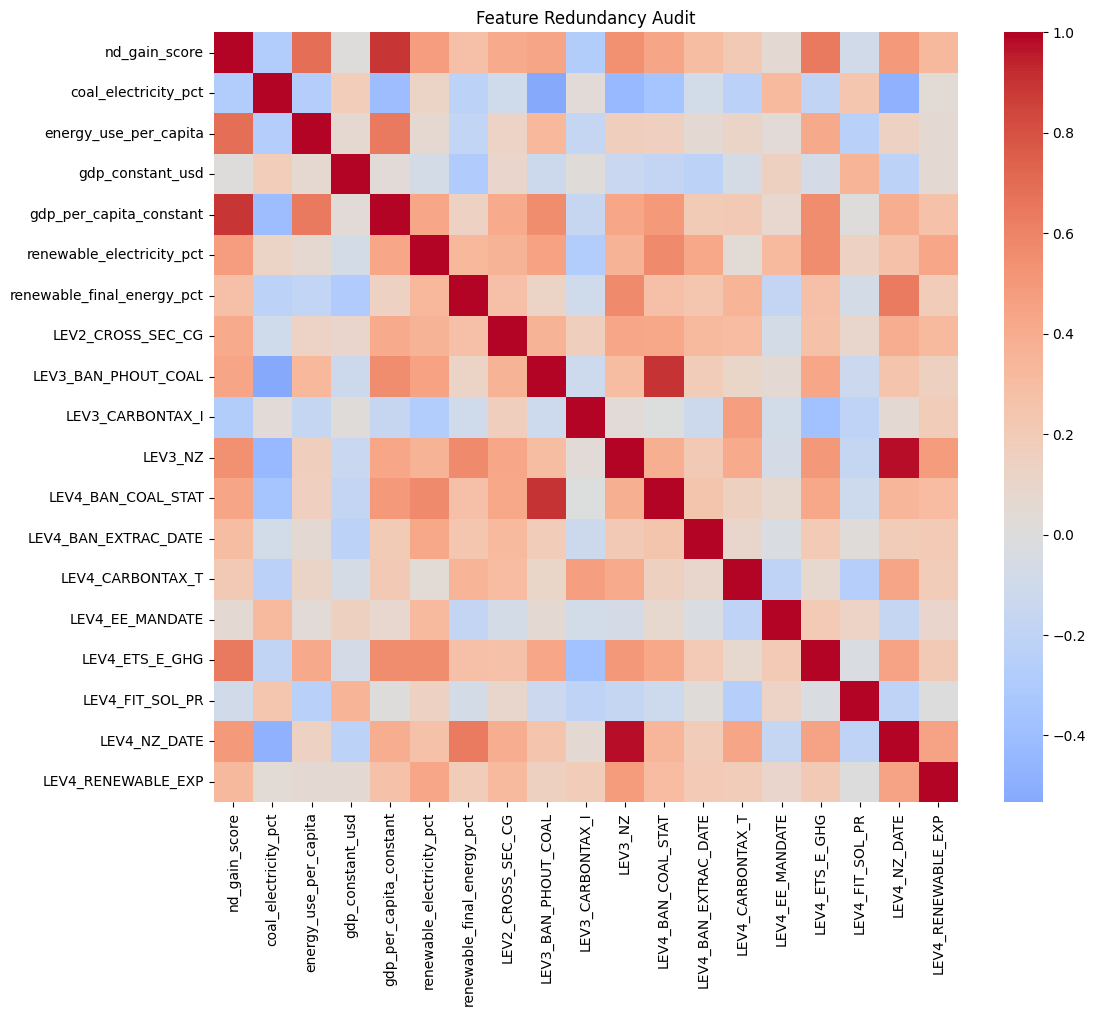

In [10]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(X_df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Redundancy Audit")